<a href="https://colab.research.google.com/github/carolonias-lgtm/Semana-1.1/blob/main/Semin%C3%A1rio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Membros do grupo
- Carolina Ferreira Onias 16859769
- Luciana Miki Sumi
- Melissa Rebechi Santana
- **Fonte**: file:///C:/Users/carolina.onias/Downloads/Dados%20semin%C3%A1rio%20de%20estat%C3%ADstica%20(1).pdf

- **Slide**:

# Proteínas


Objetivo: Analisar como o consumo de carne bovina, carne suína e peixes frescos se diferencia entre as cinco Grandes Regiões do Brasil, considerando a frequência de consumo, a quantidade média consumida e a proporção consumida fora do domicílio.

Conceitos utilizados: Frequência,média e razão.

Frequência de consumo Alimentar (%): Percentual da quantidade de vezes em que esses alimentos são consumidos.

No presente estudo, foi analisada a Frequência de consumo Alimentar da população Brasileira referente a 4 diferentes tipos de proteína animal. Inicialmente, foram obtidas as médias Gerais, em porcentagem, da frequência de consumo para cada alimento.


In [26]:
#Observando como o colab está lendo o arquivo
import pandas as pd
df = pd.read_excel('Dados seminário .xlsx')
df.head(4)

,Grupo,Alimento,Variável,Norte,Nordeste,Sudeste,Sul,Centro-Oeste
0,Proteínas,Carne bovina,Frequência (%),39.0,33.5,37.5,41.2,51.9
1,Proteínas,Carne suína,Frequência (%),3.9,4.5,6.9,10.5,9.6
2,Proteínas,Aves,Frequência (%),29.2,37.4,30.1,25.4,22.4
3,Proteínas,Peixes frescos,Frequência (%),16.6,8.2,3.3,3.1,3.9


In [15]:
proteinas = frequencia[
    frequencia['Alimento'].isin([
        'Carne bovina',
        'Aves',
        'Carne suína',
        'Peixes frescos'
    ])
].copy()

proteinas

,Grupo,Alimento,Variável,Norte,Nordeste,Sudeste,Sul,Centro-Oeste
0,Proteínas,Carne bovina,Frequência (%),39.0,33.5,37.5,41.2,51.9
1,Proteínas,Carne suína,Frequência (%),3.9,4.5,6.9,10.5,9.6
2,Proteínas,Aves,Frequência (%),29.2,37.4,30.1,25.4,22.4
3,Proteínas,Peixes frescos,Frequência (%),16.6,8.2,3.3,3.1,3.9


In [16]:
# médias Gerais, em porcentagem, da frequência de consumo para cada alimento.
regioes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']

proteinas['Média (%)'] = proteinas[regioes].mean(axis=1)

proteinas[['Alimento', 'Média (%)']]

,Alimento,Média (%)
0,Carne bovina,40.62
1,Carne suína,7.08
2,Aves,28.90
3,Peixes frescos,7.02


 - Nesta primeira análise, é possível concluir que a frequência em que tais alimentos são consumidos não é uniforme. Certos tipos são mais frequentes do que outros.
 Tal diferença é evidenciada quando comparamos a frequência de consumo Alimentar da carne bovina com a das demais proteínas.


In [17]:
media_bovina = proteinas.loc[
    proteinas['Alimento'] == 'Carne bovina',
    'Média (%)'
].iloc[0]

print(media_bovina)


40.62


In [18]:
proteinas['Razão (bovina/outra)'] = (
    media_bovina / proteinas['Média (%)']
)

proteinas[['Alimento', 'Média (%)', 'Razão (bovina/outra)']]

,Alimento,Média (%),Razão (bovina/outra)
0,Carne bovina,40.62,1.000000
1,Carne suína,7.08,5.737288
2,Aves,28.90,1.405536
3,Peixes frescos,7.02,5.786325


- A comparação foi realizada por meio da razão entre a média de frequência de consumo da carne bovina com a média dos outros alimentos. Com isso, podemos concluir que a carne bovina é a proteína mais consumida entre os Brasileiros.

Porém, essa visão geral pode ocultar diferenças importantes entre as regiões brasileiras. Ao analisarmos a frequência de consumo separadamente nas cinco Grandes Regiões do país, essa proporção varia.

In [19]:
razoes_regionais = proteinas.set_index('Alimento')[regioes].copy()

razoes_regionais

,Norte,Nordeste,Sudeste,Sul,Centro-Oeste
Alimento,,,,,
Carne bovina,39.0,33.5,37.5,41.2,51.9
Carne suína,3.9,4.5,6.9,10.5,9.6
Aves,29.2,37.4,30.1,25.4,22.4
Peixes frescos,16.6,8.2,3.3,3.1,3.9


In [22]:
razoes_regionais = razoes_regionais.loc['Carne bovina'] / razoes_regionais

razoes_regionais = razoes_regionais.round(2)

razoes_regionais

,Norte,Nordeste,Sudeste,Sul,Centro-Oeste
Alimento,,,,,
Carne bovina,1.00,1.00,1.00,1.00,1.00
Carne suína,10.00,7.69,5.56,4.00,5.56
Aves,1.33,0.89,1.25,1.61,2.33
Peixes frescos,2.33,4.17,11.11,12.50,12.50


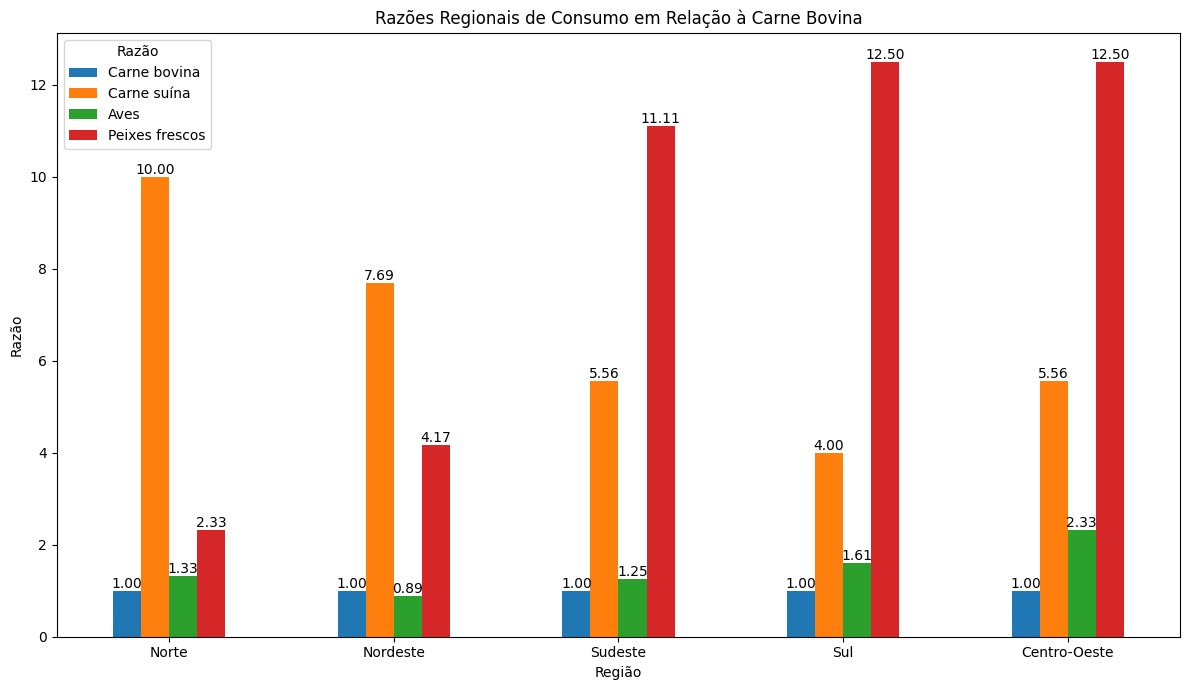

In [24]:
import matplotlib.pyplot as plt

ax = razoes_regionais.T.plot(
    kind='bar',
    figsize=(12, 7)
)

plt.xlabel('Região')
plt.ylabel('Razão')
plt.xticks(rotation=0)
plt.legend(title='Razão')
plt.title('Razões Regionais de Consumo em Relação à Carne Bovina') # Adiciona o título principal

# Adiciona os valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f') # Formata para 2 casas decimais

plt.tight_layout()

plt.show()

Contudo, podi-se concluir que a frequência em que esses alimentos são consumidos varia a depender da região. Isso ocorre pois cada região carrera um costume e uma cultura alimentar própria.

#Carboidratos
análise de consumo dos carboidratos(Cereais, arroz, milho, macarrão e macarrão instantâneo) por regiões do Brasil.

In [27]:
import io
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import files

In [ ]:
# Carregar o arquivo enviado
df = pd.read_excel('Dados seminário .xlsx')

# Filtrar apenas o grupo Cereais
tuberculos = df[df['Grupo'] == 'Cereais']

# Reestruturar as colunas de regiões para o formato longo (tidy data)
regioes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']
tub_melted = tuberculos.melt(
    id_vars=['Grupo', 'Alimento', 'Variável'],
    value_vars=regioes,
    var_name='Região',
    value_name='Valor'
)

# Visualizar a tabela reestruturada
tub_melted.head()

,Grupo,Alimento,Variável,Região,Valor
0,Cereais,Arroz,Frequência (%),Norte,73.0
1,Cereais,Milho e preparações à base de milho,Frequência (%),Norte,6.5
2,Cereais,Macarrão e preparações à base de macarrão,Frequência (%),Norte,18.9
3,Cereais,Macarrão instantâneo,Frequência (%),Norte,1.3
4,Cereais,Arroz,Consumo médio (g/dia),Norte,130.2


In [ ]:
df = pd.read_excel(io.BytesIO(uploaded[filename]))

# Filtra apenas a categoria Cereais e as duas variáveis desejadas
cereais_df = df[
    (df['Grupo'] == 'Cereais')
    & (
        df['Variável'].isin(
            ['Frequência (%)', 'Consumo médio (g/dia)']
        )
    )
]

In [ ]:
regioes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']

df_melted = cereais_df.melt(
    id_vars=['Grupo', 'Alimento', 'Variável'],
    value_vars=regioes,
    var_name='Região',
    value_name='Valor',
)

In [ ]:
df_freq = df_melted[df_melted['Variável'] == 'Frequência (%)']
df_cons = df_melted[df_melted['Variável'] == 'Consumo médio (g/dia)']

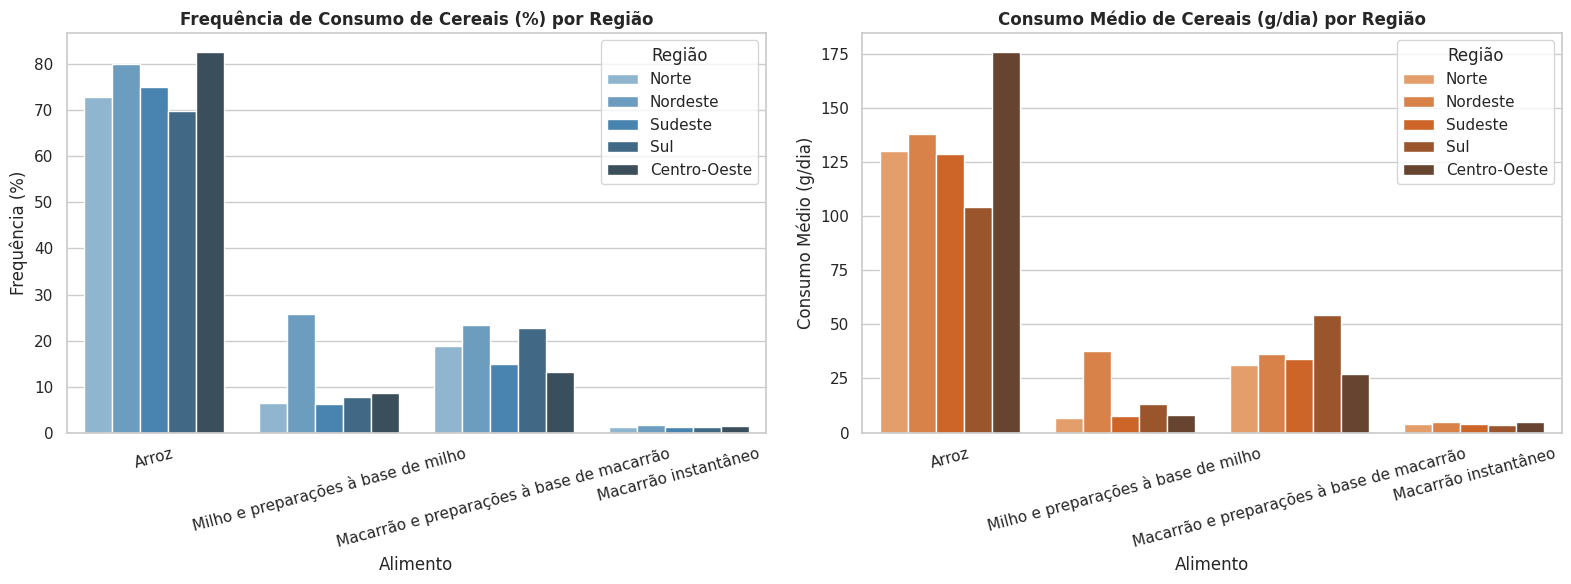

In [ ]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Frequência (%)
sns.barplot(
    data=df_freq,
    x='Alimento',
    y='Valor',
    hue='Região',
    ax=axes[0],
    palette='Blues_d',
)
axes[0].set_title(
    'Frequência de Consumo de Cereais (%) por Região',
    fontsize=12,
    fontweight='bold',
)
axes[0].set_ylabel('Frequência (%)')
axes[0].set_xlabel('Alimento')
axes[0].tick_params(axis='x', rotation=15)

# Gráfico de Consumo Médio (g/dia)
sns.barplot(
    data=df_cons,
    x='Alimento',
    y='Valor',
    hue='Região',
    ax=axes[1],
    palette='Oranges_d',
)
axes[1].set_title(
    'Consumo Médio de Cereais (g/dia) por Região',
    fontsize=12,
    fontweight='bold',
)
axes[1].set_ylabel('Consumo Médio (g/dia)')
axes[1].set_xlabel('Alimento')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Tubérculo

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Carregar o arquivo enviado
df = pd.read_excel('Dados seminário .xlsx')

# Filtrar apenas o grupo Tubérculos
tuberculos = df[df['Grupo'] == 'Tubérculos']

# Reestruturar as colunas de regiões para o formato longo (tidy data)
regioes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']
tub_melted = tuberculos.melt(
    id_vars=['Grupo', 'Alimento', 'Variável'],
    value_vars=regioes,
    var_name='Região',
    value_name='Valor'
)

# Visualizar a tabela reestruturada
tub_melted.head()

,Grupo,Alimento,Variável,Região,Valor
0,Tubérculos,Farinha de mandioca,Frequência (%),Norte,40.6
1,Tubérculos,Batata-inglesa,Frequência (%),Norte,1.8
2,Tubérculos,Batata-doce,Frequência (%),Norte,1.0
3,Tubérculos,Farinha de mandioca,Consumo médio (g/dia),Norte,38.0
4,Tubérculos,Batata-inglesa,Consumo médio (g/dia),Norte,2.2


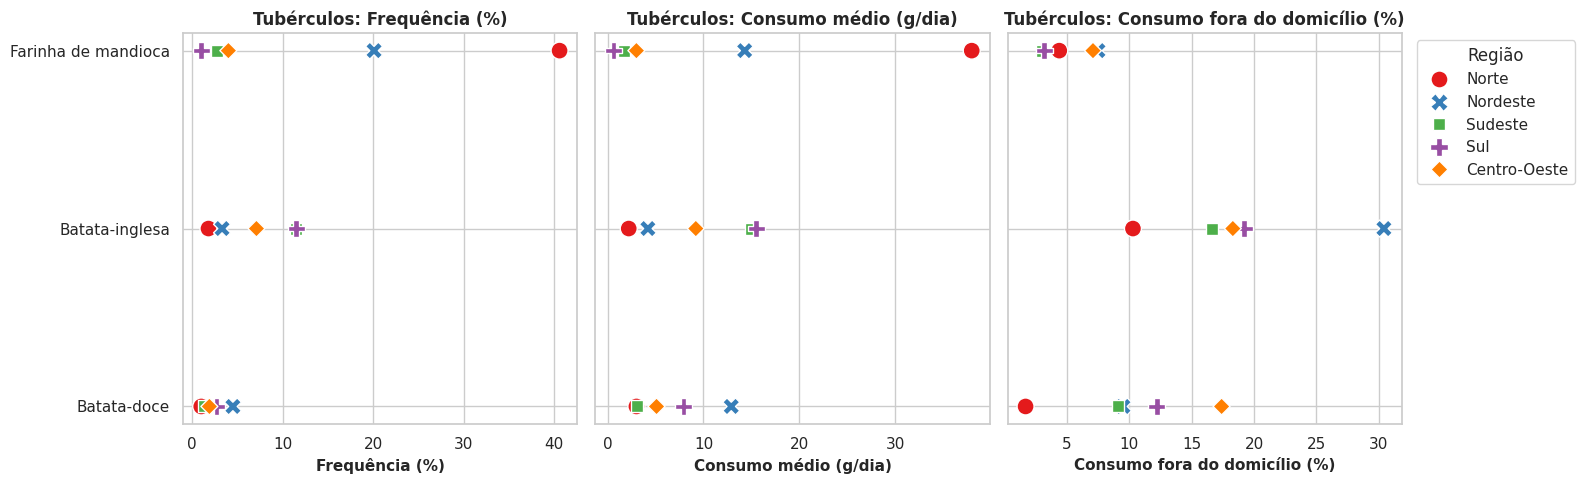

In [ ]:
# Configurar estilo visual
sns.set_theme(style="whitegrid")

# Criar 3 painéis lado a lado compartilhando o eixo Y
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
variaveis = tub_melted['Variável'].unique()

for i, var in enumerate(variaveis):
    sub = tub_melted[tub_melted['Variável'] == var]

    sns.scatterplot(
        data=sub,
        x='Valor',
        y='Alimento',
        hue='Região',
        style='Região',
        s=150,
        ax=axes[i],
        palette='Set1'
    )

    axes[i].set_title(f'Tubérculos: {var}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel(var, fontweight='bold', fontsize=11)
    axes[i].set_ylabel('')

    # Exibe a legenda apenas no último painel
    if i < 2:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title='Região', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

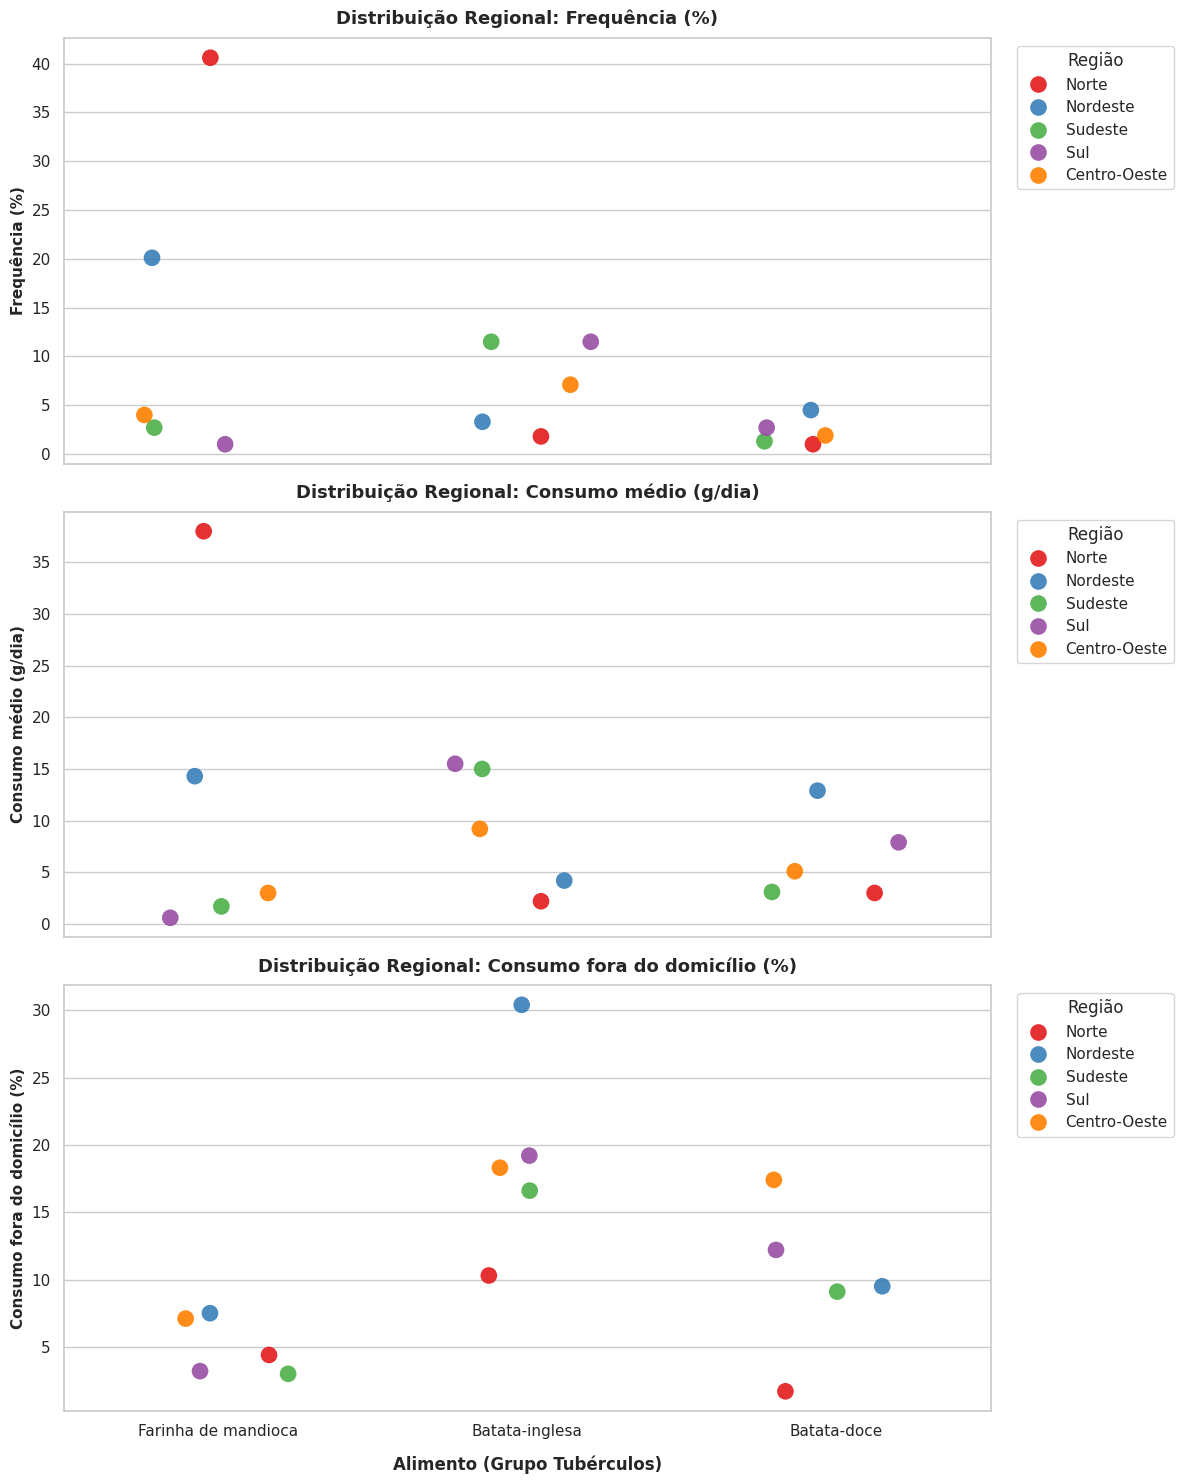

In [ ]:
# Configurar o painel vertical com espaçamento expandido
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
plt.subplots_adjust(hspace=0.35)

for i, var in enumerate(variaveis):
    sub = tub_melted[tub_melted['Variável'] == var]

    sns.stripplot(
        data=sub,
        x='Alimento',
        y='Valor',
        hue='Região',
        jitter=0.25,      # Afasta os pontos para não sobrepor
        size=12,          # Aumenta o tamanho das bolinhas
        alpha=0.9,
        ax=axes[i],
        palette='Set1'
    )

    axes[i].set_title(f'Distribuição Regional: {var}', fontweight='bold', fontsize=13, pad=10)
    axes[i].set_ylabel(var, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=11)
    axes[i].legend(title='Região', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

# Ajustar rótulo da base
axes[2].set_xlabel('Alimento (Grupo Tubérculos)', fontweight='bold', fontsize=12, labelpad=12)

plt.tight_layout()
plt.show()

#Frequência  de consumo de açaí, banana, maçã, laranja, chuchu e salada crua pelas diferentes regiões do Brasil.

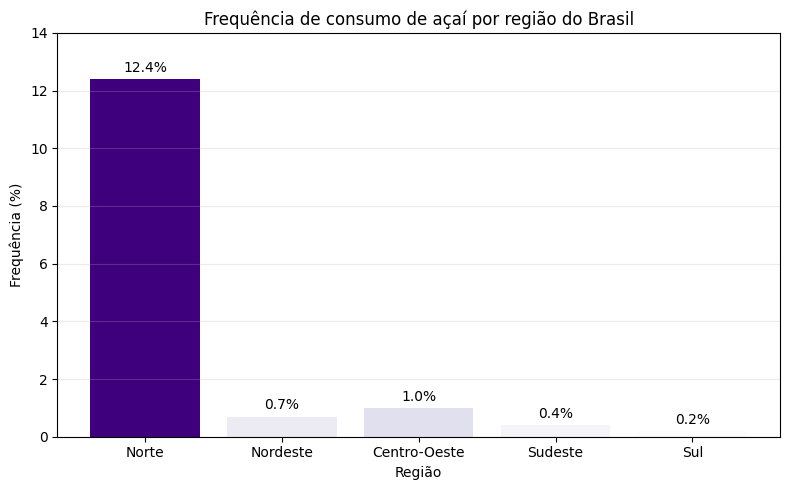

In [ ]:
#Açaí
import matplotlib.pyplot as plt
import numpy as np

# Regiões
regioes = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]

# Frequência (%) de consumo de açaí
frequencia_acai = [12.4, 0.7, 1.0, 0.4, 0.2]

# Criando o gráfico
plt.figure(figsize=(8, 5))

# Aplicar transformação logarítmica para espaçar melhor os valores pequenos
log_frequencia_acai = np.log1p(frequencia_acai)

# Gerar cores em gradiente de roxo usando a escala logarítmica
colormap = plt.cm.Purples
norm = plt.Normalize(vmin=min(log_frequencia_acai), vmax=max(log_frequencia_acai))
colors = [colormap(norm(value)) for value in log_frequencia_acai]

barras = plt.bar(regioes, frequencia_acai, color=colors)

plt.title("Frequência de consumo de açaí por região do Brasil")
plt.xlabel("Região")
plt.ylabel("Frequência (%)")

# Limite do eixo Y
plt.ylim(0, 14)

# Grade horizontal
plt.grid(axis="y", alpha=0.25)

# Valores sobre as colunas
for barra, valor in zip(barras, frequencia_acai):
    plt.text(
        barra.get_x() + barra.get_width()/2,
        valor + 0.25,
        f"{valor:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

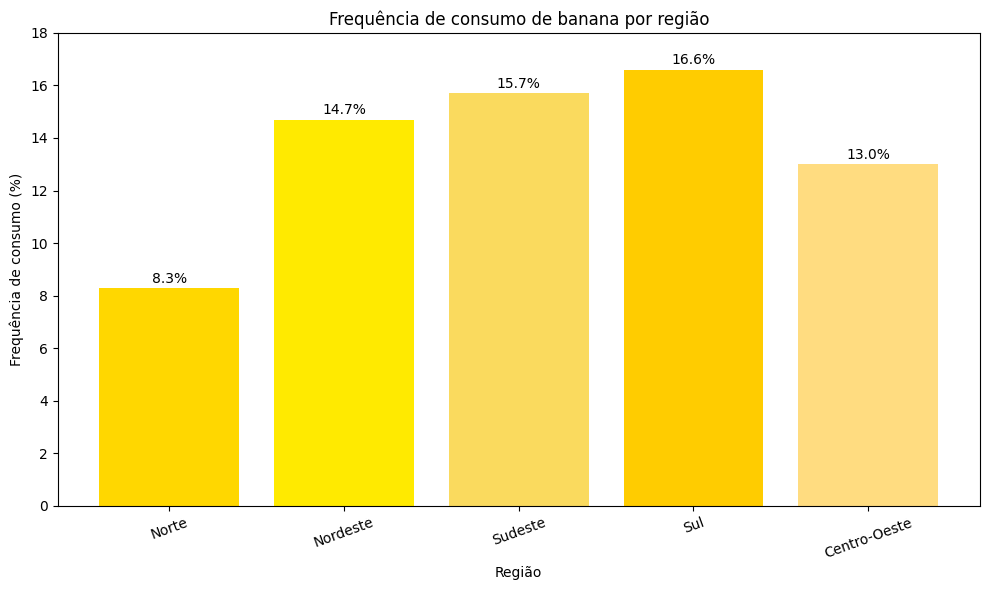

In [ ]:
##Banana
import matplotlib.pyplot as plt
import numpy as np

# Regiões do Brasil
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

# Frequência de consumo de banana (%)
banana = [8.3, 14.7, 15.7, 16.6, 13.0]

# Criando o gráfico
plt.figure(figsize=(10, 6))

# Definir uma lista de cores amarelas com variações sutis
bar_colors = [
    '#FFD700', # Gold
    '#FFEA00', # Bright Yellow
    '#FADA5E', # Lemon Curry
    '#FFCC00', # Goldenrod
    '#FFDC80'  # Light Goldenrod
]

plt.bar(regioes, banana, color=bar_colors)

# Título e nomes dos eixos
plt.title("Frequência de consumo de banana por região")
plt.xlabel("Região")
plt.ylabel("Frequência de consumo (%)")

# Valores acima das colunas
for i, valor in enumerate(banana):
    plt.text(i, valor + 0.2, f"{valor:.1f}%", ha="center")

# Ajustes
plt.xticks(rotation=20)
plt.ylim(0, 18)
plt.tight_layout()

# Mostrar gráfico
plt.show()

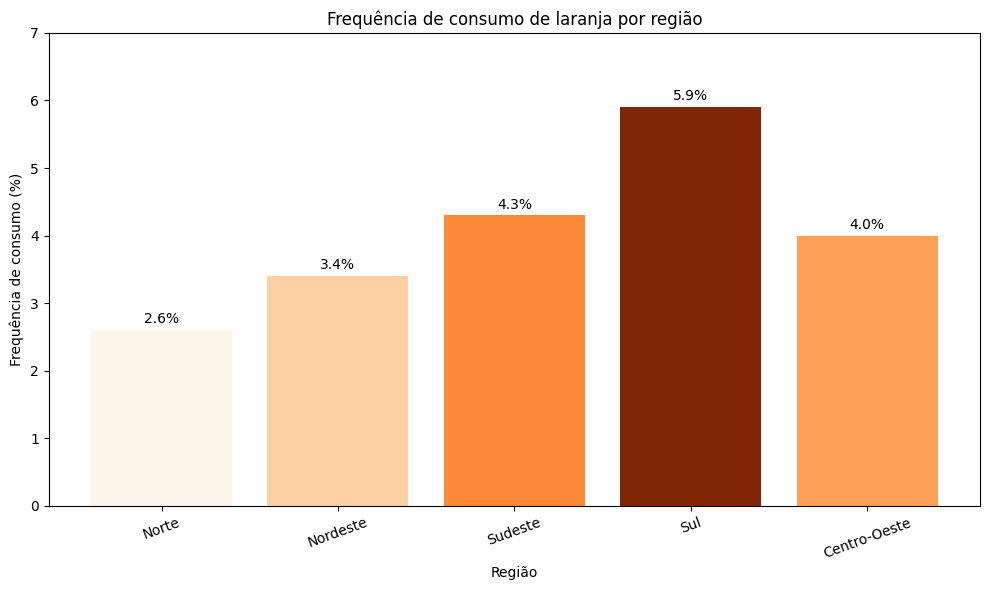

In [ ]:
#Laranja
import matplotlib.pyplot as plt
import numpy as np

# Regiões do Brasil
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

# Frequência de consumo de laranja (%)
laranja = [2.6, 3.4, 4.3, 5.9, 4.0]

# Criando o gráfico
plt.figure(figsize=(10, 6))

# Gerar cores em gradiente de laranja
colormap = plt.cm.Oranges
norm = plt.Normalize(vmin=min(laranja), vmax=max(laranja))
colors = [colormap(norm(value)) for value in laranja]

plt.bar(regioes, laranja, color=colors)

# Título e nomes dos eixos
plt.title("Frequência de consumo de laranja por região")
plt.xlabel("Região")
plt.ylabel("Frequência de consumo (%)")

# Valores acima das colunas
for i, valor in enumerate(laranja):
    plt.text(i, valor + 0.1, f"{valor:.1f}%", ha="center")

# Ajustes
plt.xticks(rotation=20)
plt.ylim(0, 7)
plt.tight_layout()

# Mostrar gráfico
plt.show()

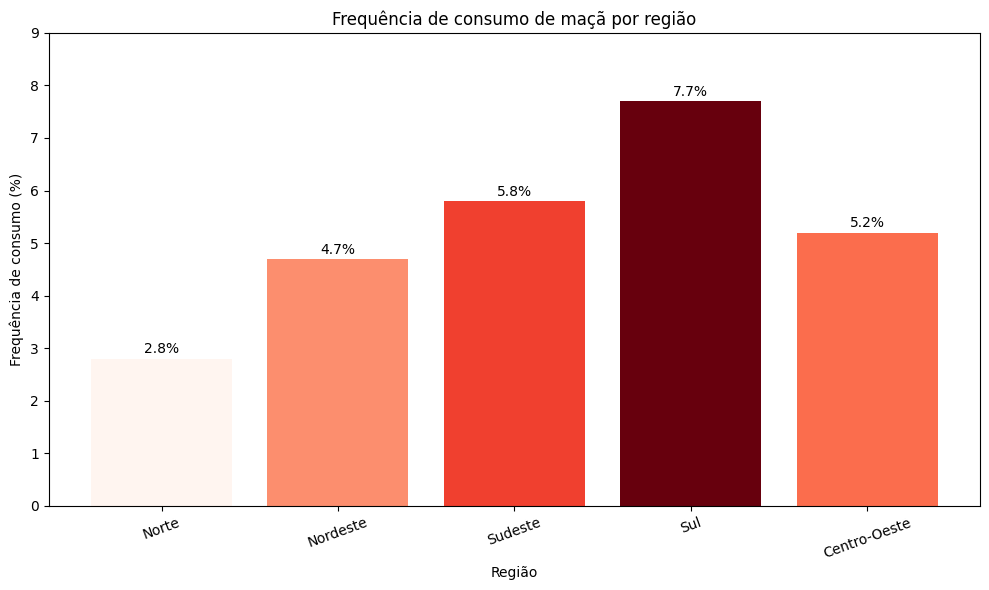

In [ ]:
#Maçã
import matplotlib.pyplot as plt
import numpy as np

# Regiões do Brasil
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

# Frequência de consumo de maçã (%)
maca = [2.8, 4.7, 5.8, 7.7, 5.2]

# Criando o gráfico
plt.figure(figsize=(10, 6))

# Gerar cores em gradiente de vermelho
colormap = plt.cm.Reds
norm = plt.Normalize(vmin=min(maca), vmax=max(maca))
colors = [colormap(norm(value)) for value in maca]

plt.bar(regioes, maca, color=colors)

# Título e nomes dos eixos
plt.title("Frequência de consumo de maçã por região")
plt.xlabel("Região")
plt.ylabel("Frequência de consumo (%)")

# Valores acima das colunas
for i, valor in enumerate(maca):
    plt.text(i, valor + 0.1, f"{valor:.1f}%", ha="center")

# Ajustes
plt.xticks(rotation=20)
plt.ylim(0, 9)
plt.tight_layout()

# Mostrar gráfico
plt.show()

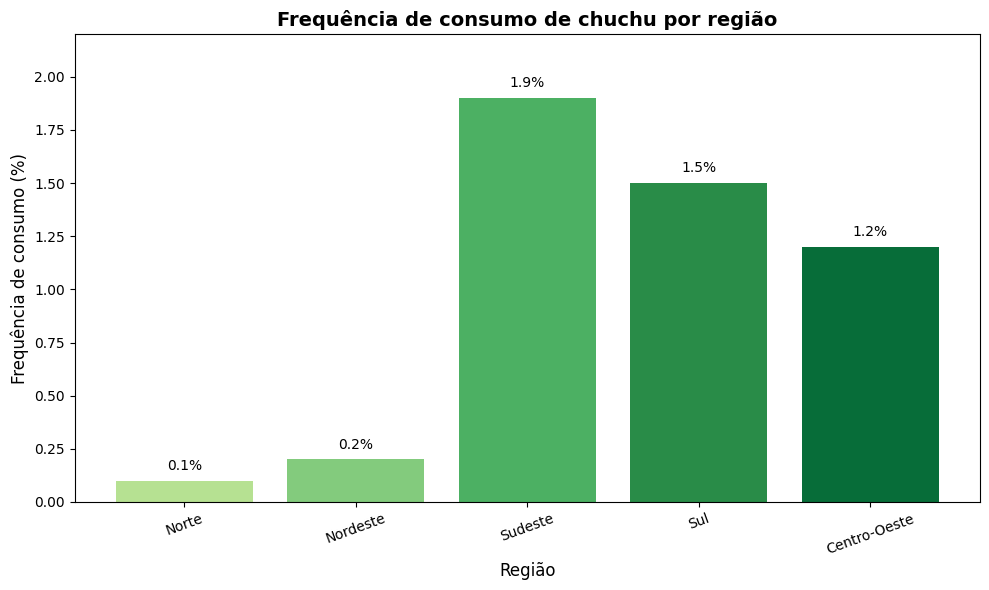

In [ ]:
#Chuchu
import matplotlib.pyplot as plt
import numpy as np

# Regiões do Brasil
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

# Frequência de consumo de chuchu (%)
chuchu = [0.1, 0.2, 1.9, 1.5, 1.2]

# Criando o gráfico
plt.figure(figsize=(10, 6))

# Gradiente em tons de verde-lima
cores = plt.cm.YlGn(np.linspace(0.35, 0.85, len(regioes)))

plt.bar(regioes, chuchu, color=cores)

# Título e eixos
plt.title("Frequência de consumo de chuchu por região",
          fontsize=14, fontweight="bold")
plt.xlabel("Região", fontsize=12)
plt.ylabel("Frequência de consumo (%)", fontsize=12)

# Valores acima das colunas
for i, valor in enumerate(chuchu):
    plt.text(i, valor + 0.05, f"{valor:.1f}%",
             ha="center", fontsize=10)

# Ajustes
plt.xticks(rotation=20)
plt.ylim(0, 2.2)
plt.tight_layout()

# Mostrar gráfico
plt.show()

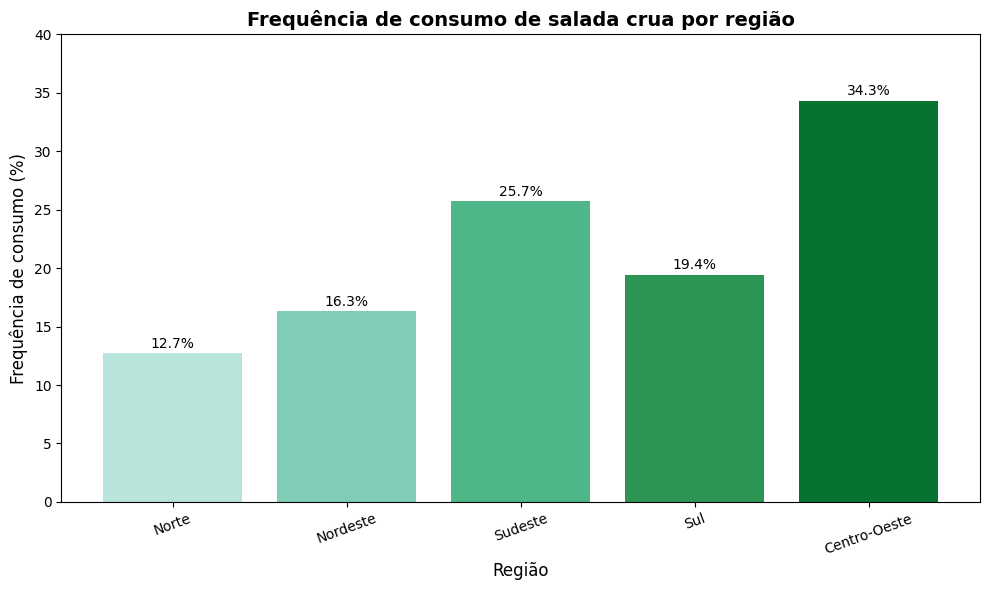

In [ ]:
#Salada crua
import matplotlib.pyplot as plt
import numpy as np

# Regiões do Brasil
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

# Frequência de consumo de salada crua (%)
salada_crua = [12.7, 16.3, 25.7, 19.4, 34.3]

# Criando o gráfico
plt.figure(figsize=(10, 6))

# Gradiente em tons de verde-água
cores = plt.cm.BuGn(np.linspace(0.30, 0.85, len(regioes)))

plt.bar(regioes, salada_crua, color=cores)

# Título e eixos
plt.title("Frequência de consumo de salada crua por região",
          fontsize=14, fontweight="bold")
plt.xlabel("Região", fontsize=12)
plt.ylabel("Frequência de consumo (%)", fontsize=12)

# Valores acima das colunas
for i, valor in enumerate(salada_crua):
    plt.text(i, valor + 0.5, f"{valor:.1f}%",
             ha="center", fontsize=10)

# Ajustes
plt.xticks(rotation=20)
plt.ylim(0, 40)
plt.tight_layout()

# Mostrar gráfico
plt.show()